<a href="https://colab.research.google.com/github/Amruda-glitch/Hands-on-Training/blob/main/Deep_Learning_Analysis_on_mnist_(MNIST)_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!pip install tensorflow

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

mnist -->  MNIST (Modified National Institute of Standards and Technology) dataset is a cornerstone database in machine learning, where dataset is handwritten numbers are stored , which is imported from keras library

In [32]:
mnist = keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=x_train/255.0, x_test/255.0

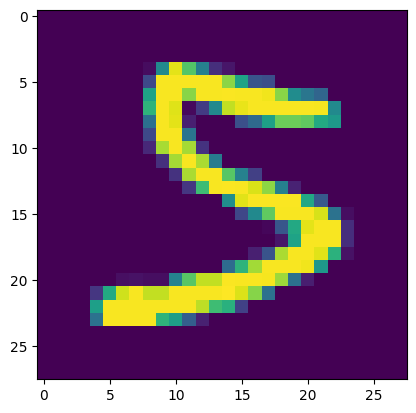

In [33]:
import matplotlib.pyplot as plt
plt.imshow(x_train[544])

In [34]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)), # 1 - Channel
    layers.Dense(128, activation='relu'), # 128 --> if its not efficient in running epochs using 128 as avg, increasing the values 256, 512 may slow down epochs
    layers.Dense(10, activation='softmax')
])

In [35]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
start = model.fit(x_train,y_train,validation_split=0.1, epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9202 - loss: 0.2788 - val_accuracy: 0.9620 - val_loss: 0.1315
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9640 - loss: 0.1239 - val_accuracy: 0.9733 - val_loss: 0.0921
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9746 - loss: 0.0860 - val_accuracy: 0.9758 - val_loss: 0.0826
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9803 - loss: 0.0646 - val_accuracy: 0.9733 - val_loss: 0.0863
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9851 - loss: 0.0502 - val_accuracy: 0.9775 - val_loss: 0.0719
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.9785 - val_loss: 0.0766
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9903 - loss: 0.0318 - val_accuracy: 0.9782 - val_loss: 0.0765
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9925 - loss: 0.025

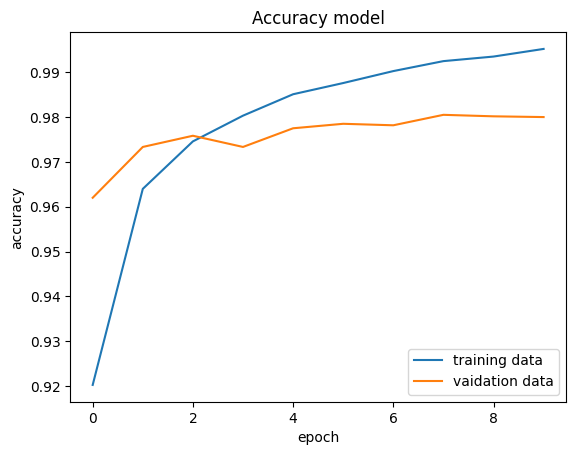

In [37]:
plt.plot(start.history['accuracy'])
plt.plot(start.history['val_accuracy'])
plt.title('Accuracy model')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data', 'vaidation data'], loc='lower right')


In [38]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [39]:
y_pred[5000]

array([3.8869343e-09, 7.9180512e-10, 2.7116266e-07, 9.9998790e-01,
       5.0233481e-12, 1.0821251e-05, 4.4812190e-10, 1.5156223e-11,
       1.0078788e-06, 2.3680033e-10], dtype=float32)

In [40]:
import numpy as np
y_pred1 = np.argmax(y_pred, axis=1)
y_pred1[5000]

np.int64(3)

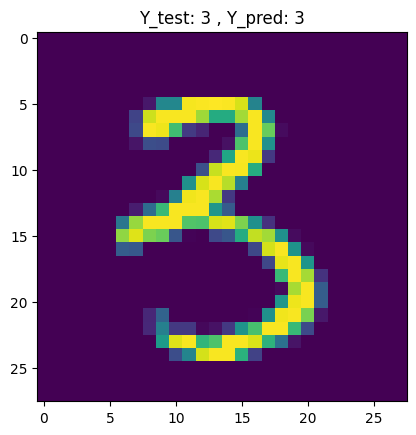

In [41]:
import matplotlib.pyplot as plt
plt.imshow(x_test[5000])
plt.title(f"Y_test: {y_test[5000]} , Y_pred: {y_pred1[5000]}")
plt.show()

In [42]:
model.save('mnist.h5')

In [43]:
from google.colab import files
files.download('mnist.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>